USE CASE 2 : Loan Default Risk Analysis

In [2]:
#Importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [3]:
df = pd.read_csv('../dataset/hdfc_loan_dataset_full_enriched_cleaned.csv')
#df.head()
df.shape
#df.info()
df.describe()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
count,997.000000,997.0,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,...,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,9.970000e+02,9.970000e+02,997.000000,997.000000
mean,500.472417,0.0,18.565697,0.674022,0.590772,0.851555,0.283852,1.426279,42143.596790,9756.383149,...,10.186805,0.968907,2.239719,4.576730,13.919759,509443.860582,4.857931e+11,9.500046e+09,18.565697,8.689067
std,288.601980,0.0,12.663110,0.491961,0.491938,0.965276,0.451092,0.759036,27681.458251,20592.272967,...,25.450030,0.822644,0.683796,2.828672,8.371614,288793.519020,2.926414e+11,2.874954e+08,12.663110,5.331163
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.003000,0.000000,0.000000,0.000000,0.000000,622.000000,2.589553e+08,9.002443e+09,0.000000,0.000000
25%,251.000000,0.0,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18251.000000,0.000000,...,0.647000,0.000000,2.000000,2.000000,7.000000,263474.000000,2.190000e+11,9.252986e+09,4.000000,4.000000
50%,501.000000,0.0,18.000000,1.000000,1.000000,1.000000,0.000000,1.000000,40668.000000,0.000000,...,2.299000,1.000000,2.000000,5.000000,14.000000,517291.000000,4.760000e+11,9.498194e+09,18.000000,9.000000
75%,750.000000,0.0,31.000000,1.000000,1.000000,2.000000,1.000000,2.000000,60874.000000,8135.000000,...,8.386000,2.000000,2.000000,7.000000,21.000000,756168.000000,7.300000e+11,9.750362e+09,31.000000,13.000000
max,999.000000,0.0,40.000000,2.000000,1.000000,3.000000,1.000000,3.000000,124758.000000,123461.000000,...,269.754000,2.000000,4.000000,9.000000,28.000000,998910.000000,9.990000e+11,9.999102e+09,40.000000,17.000000


In [5]:
df['High_Risk'] = np.where(
    df['Default_History_Count'] > 0,
    1,
    0
)

In [6]:
df['High_Risk'].value_counts()

High_Risk
0    903
1     94
Name: count, dtype: int64

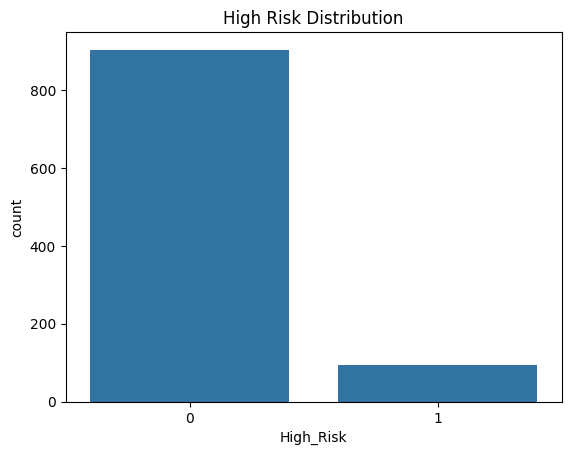

In [7]:
sns.countplot(x='High_Risk', data=df)
plt.title("High Risk Distribution")
plt.show()

In [9]:
features = [
    'Debt_to_Income_Ratio',
    'Existing_EMIs',
    'CIBIL_Score',
    'Employment_Length_Years',
    'Annual_Household_Income',
    'Loan_to_Annual_Income'
]

In [10]:
#Define X and Y
X = df[features]
y = df['High_Risk']

In [13]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#Training Model 1 : Logistic Regression
lr = LogisticRegression(
    max_iter=1000
)
lr.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
#Training Model 2 : Random Forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(
    X_train,
    y_train
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [19]:
#Making predictions
lr_pred = lr.predict(
    X_test_scaled
)
rf_pred = rf.predict(
    X_test
)
gb_pred = gb.predict(
    X_test
)

In [21]:
#Evaluating Models
#Helper Function
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    print(f"\n{model_name}")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )

    print(
        "F1:",
        f1_score(y_true, y_pred)
    )

In [22]:
evaluate_model(y_test, lr_pred, "Logistic")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, gb_pred, "Gradient Boosting")


Logistic
Accuracy: 0.905
Precision: 0.0
Recall: 0.0
F1: 0.0

Random Forest
Accuracy: 0.905
Precision: 0.0
Recall: 0.0
F1: 0.0

Gradient Boosting
Accuracy: 0.895
Precision: 0.0
Recall: 0.0
F1: 0.0


c:\Users\User\Desktop\hdfc ml project\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\hdfc ml project\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


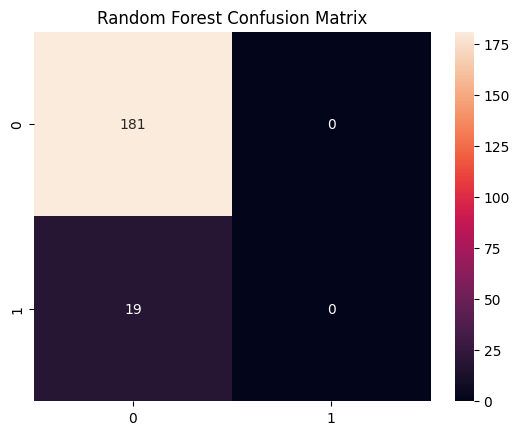

In [23]:
#Creating Confusion Matrix HeatMap
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [24]:
y.value_counts(normalize=True) * 100

High_Risk
0    90.571715
1     9.428285
Name: proportion, dtype: float64

In [25]:
!pip install imbalanced-learn

In [26]:
#Applying SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [27]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

High_Risk
0    722
1     75
Name: count, dtype: int64
High_Risk
0    722
1    722
Name: count, dtype: int64


In [28]:
#Retraining models using SMOTE data
#Logistic Regression with SMOTE
lr_smote = LogisticRegression(
    max_iter=1000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
#Random Forest with SMOTE
rf_smote = RandomForestClassifier(
    random_state=42
)
rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
#Gradient Boosting with SMOTE
gb_smote = GradientBoostingClassifier(
    random_state=42
)
gb_smote.fit(
    X_train_smote,
    y_train_smote
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [31]:
#Predict again with SMOTE models
rf_pred_smote = rf_smote.predict(X_test)

gb_pred_smote = gb_smote.predict(X_test)

lr_pred_smote = lr_smote.predict(X_test)

In [32]:
#Evaluating SMOTE Models
evaluate_model(y_test, lr_pred_smote, "Logistic")
evaluate_model(y_test, rf_pred_smote, "Random Forest")
evaluate_model(y_test, gb_pred_smote, "Gradient Boosting") 


Logistic
Accuracy: 0.745
Precision: 0.2037037037037037
Recall: 0.5789473684210527
F1: 0.3013698630136986

Random Forest
Accuracy: 0.805
Precision: 0.16666666666666666
Recall: 0.2631578947368421
F1: 0.20408163265306123

Gradient Boosting
Accuracy: 0.755
Precision: 0.10526315789473684
Recall: 0.21052631578947367
F1: 0.14035087719298245


In [33]:
rf_prob = rf_smote.predict_proba(
    X_test
)[:,1]

In [34]:
roc_auc = roc_auc_score(
    y_test,
    rf_prob
)
print("ROC AUC:", roc_auc)

ROC AUC: 0.6671997673742368


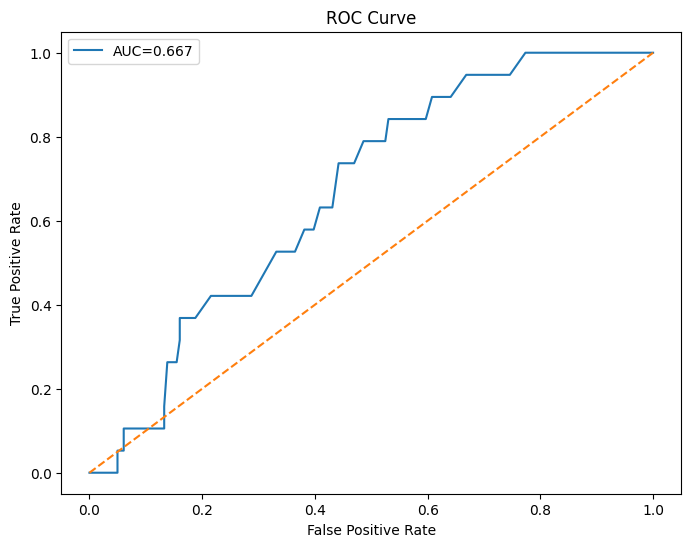

In [35]:
#Plotting ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [36]:
plt.savefig(
    "../visuals/risk_roc_curve.png"
)

<Figure size 640x480 with 0 Axes>

In [37]:
#Hyperparameter Tuning
#using GridSearchCV
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators':[100,200],

    'max_depth':[5,10,15],

    'min_samples_split':[2,5],

    'min_samples_leaf':[1,2]
}

In [38]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [39]:
#Train Grid Search
grid.fit(
    X_train_smote,
    y_train_smote
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [40]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [41]:
best_rf = grid.best_estimator_

In [42]:
#Evaluate Tuned Model
best_pred = best_rf.predict(
    X_test
)

evaluate_model(
    y_test,
    best_pred,
    "Tuned RF"
)


Tuned RF
Accuracy: 0.765
Precision: 0.1111111111111111
Recall: 0.21052631578947367
F1: 0.14545454545454545


In [44]:
#Comparing All models
recall_lr = recall_score(y_test, lr_pred)
recall_rf = recall_score(y_test, rf_pred)
recall_gb = recall_score(y_test, gb_pred)
recall_best = recall_score(y_test, best_pred)

results = pd.DataFrame({
    'Model': ['Logistic', 'Random Forest', 'Gradient Boosting', 'Tuned RF'],
    'Recall': [recall_lr, recall_rf, recall_gb, recall_best]
})

results

,Model,Recall
0,Logistic,0.000000
1,Random Forest,0.000000
2,Gradient Boosting,0.000000
3,Tuned RF,0.210526


In [45]:
#Feature Importance
importance = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})

In [47]:
#Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

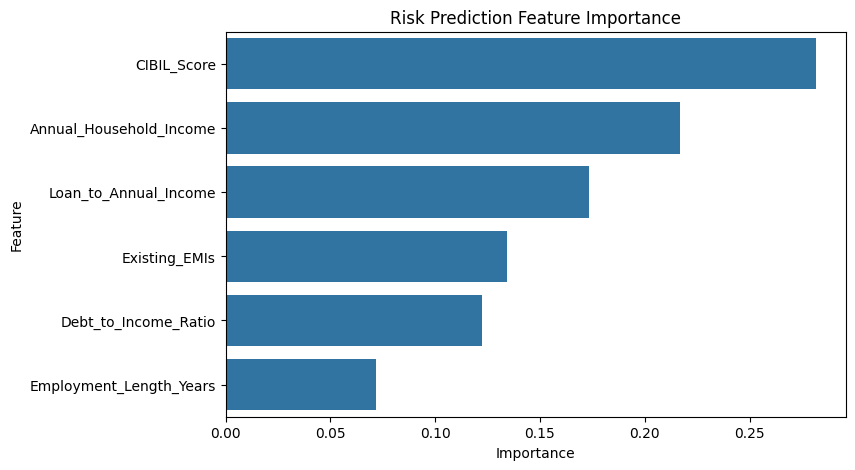

In [48]:
#Visualize
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title(
    "Risk Prediction Feature Importance"
)
plt.show()

In [49]:
df_risk = df.copy()

In [50]:
df_risk['Predicted_Risk'] = best_rf.predict(X)

In [51]:
#Separate high risk customers
high_risk_customers = df_risk[
    df_risk['Predicted_Risk'] == 1
]

In [53]:
#Check Count
high_risk_customers.shape #195 customers identifies as risky

(195, 49)

In [54]:
high_risk_customers['CIBIL_Score'].mean()
high_risk_customers['Debt_to_Income_Ratio'].mean()
high_risk_customers['Existing_EMIs'].mean()
high_risk_customers['Annual_Household_Income'].mean()

np.float64(695999.0153846154)

In [56]:
#Compare Safe vs Risky customers
safe_customers = df_risk[
    df_risk['Predicted_Risk'] == 0
]

In [57]:
comparison = pd.DataFrame({

    'Safe':[
        safe_customers['CIBIL_Score'].mean(),
        safe_customers['Debt_to_Income_Ratio'].mean(),
        safe_customers['Existing_EMIs'].mean()
    ],

    'High Risk':[
        high_risk_customers['CIBIL_Score'].mean(),
        high_risk_customers['Debt_to_Income_Ratio'].mean(),
        high_risk_customers['Existing_EMIs'].mean()
    ]

},

index=[
    'CIBIL',
    'Debt Ratio',
    'EMI'
])

comparison

,Safe,High Risk
CIBIL,664.889027,604.000000
Debt Ratio,184.550111,0.557754
EMI,19135.942643,14357.374359


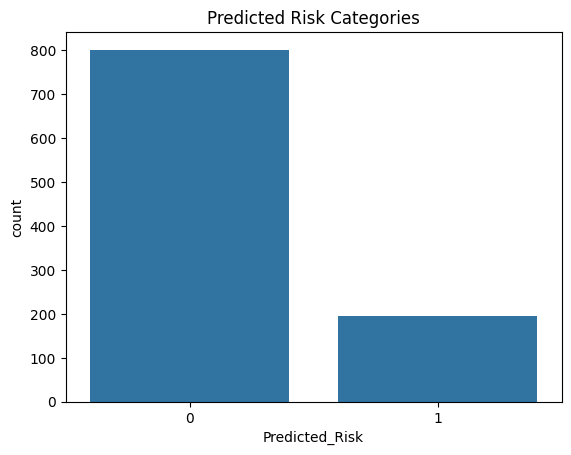

In [59]:
#Visualize 1
#Risk Category Distribution
sns.countplot(
    x='Predicted_Risk',
    data=df_risk
)

plt.title(
    "Predicted Risk Categories"
)

plt.show()

In [60]:
plt.savefig(
    "../visuals/risk_distribution.png"
)

<Figure size 640x480 with 0 Axes>

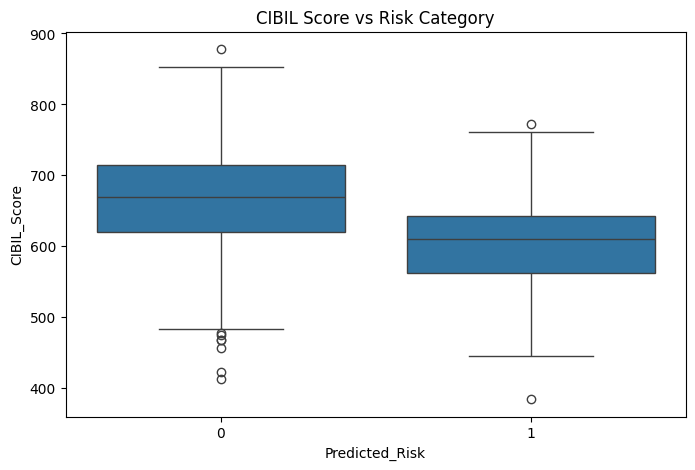

In [61]:
#Visualize 2 
#CIBIL SCORE by risk category
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Predicted_Risk',
    y='CIBIL_Score',
    data=df_risk
)

plt.title(
    "CIBIL Score vs Risk Category"
)

plt.show()

In [62]:
plt.savefig(
    "../visuals/cibil_risk_analysis.png"
)

<Figure size 640x480 with 0 Axes>

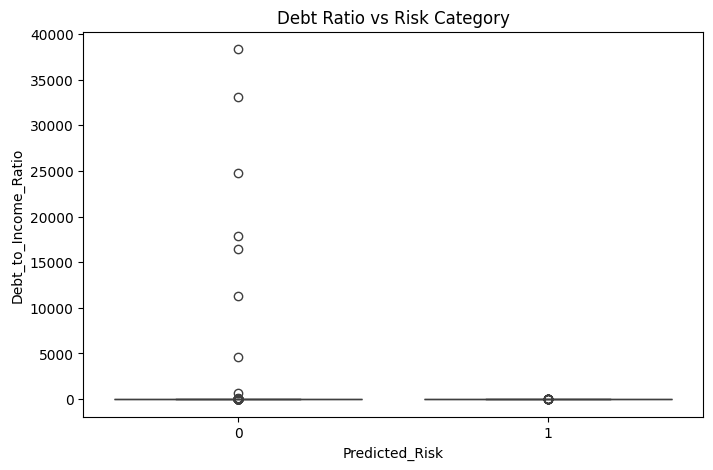

In [63]:
#Visualize 3 
#Debt to income ratio Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Predicted_Risk',
    y='Debt_to_Income_Ratio',
    data=df_risk
)

plt.title(
    "Debt Ratio vs Risk Category"
)

plt.show()

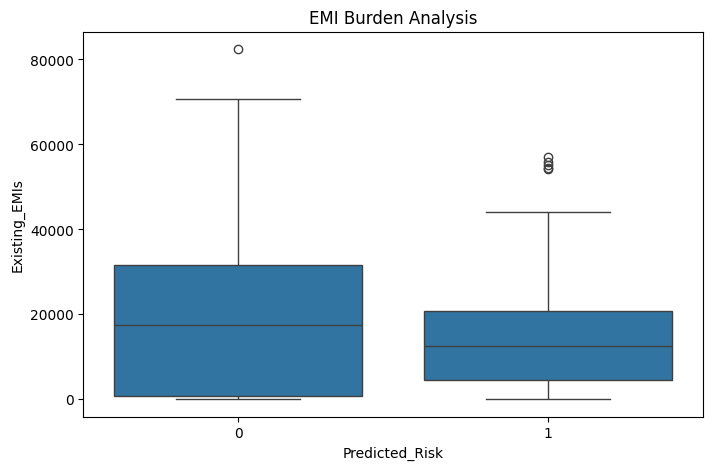

In [64]:
#Visualize 4
#EMI burden Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Predicted_Risk',
    y='Existing_EMIs',
    data=df_risk
)

plt.title(
    "EMI Burden Analysis"
)

plt.show()

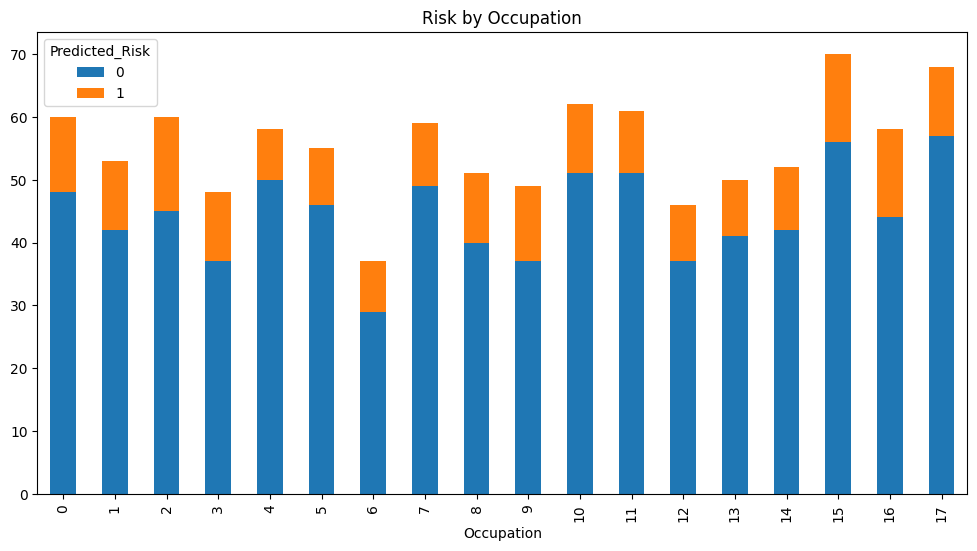

In [65]:
#Visualize 5
#Occupation Risk Analysis
occupation_risk = pd.crosstab(
    df_risk['Occupation'],
    df_risk['Predicted_Risk']
)
occupation_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Risk by Occupation"
)

plt.show()

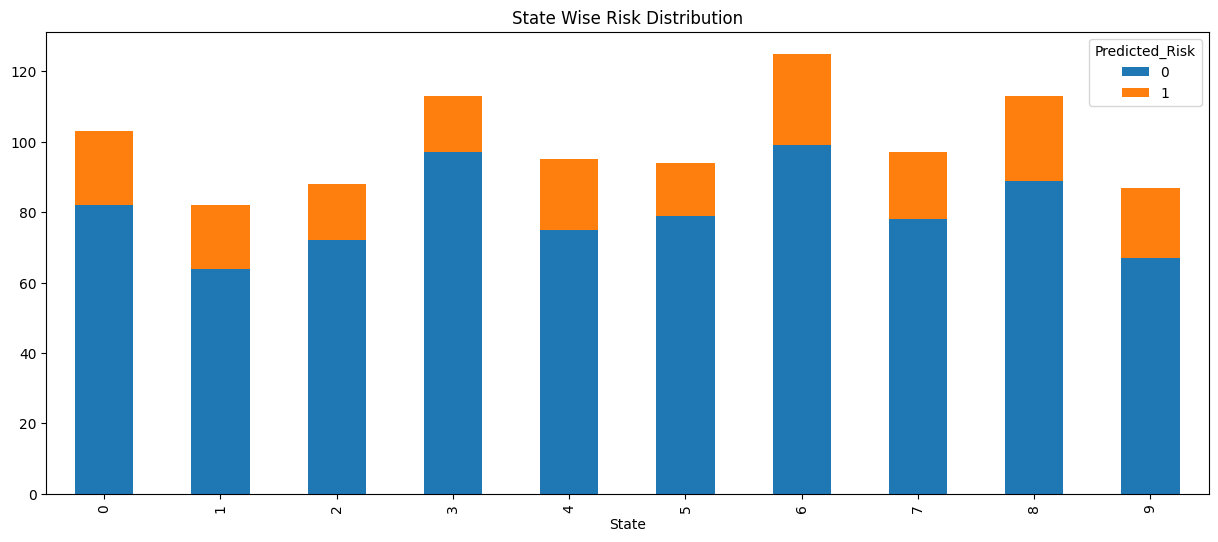

In [66]:
#Visualize 6
#State wise risk analysis
state_risk = pd.crosstab(
    df_risk['State'],
    df_risk['Predicted_Risk']
)
state_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(15,6)
)

plt.title(
    "State Wise Risk Distribution"
)

plt.show() 

In [68]:
#Saving best model
joblib.dump(
    best_rf,
    "../models/risk_model.pkl"
)

['../models/risk_model.pkl']

In [69]:
#Saving scaler
joblib.dump(
    scaler,
    "../models/risk_scaler.pkl"
)

['../models/risk_scaler.pkl']

In [71]:
#Verifying Saved model
loaded_model = joblib.load(
    "../models/risk_model.pkl"
)

In [72]:
loaded_model.predict(X_test)

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1])

In [74]:
# Compute evaluation metrics before creating the results table
acc_lr = accuracy_score(y_test, lr_pred)
acc_rf = accuracy_score(y_test, rf_pred)
acc_gb = accuracy_score(y_test, gb_pred)
acc_best = accuracy_score(y_test, best_pred)

recall_lr = recall_score(y_test, lr_pred)
recall_rf = recall_score(y_test, rf_pred)
recall_gb = recall_score(y_test, gb_pred)
recall_best = recall_score(y_test, best_pred)

f1_lr = f1_score(y_test, lr_pred)
f1_rf = f1_score(y_test, rf_pred)
f1_gb = f1_score(y_test, gb_pred)
f1_best = f1_score(y_test, best_pred)

auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
auc_gb = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
auc_best = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

# Create results table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_rf,
        acc_gb,
        acc_best
    ],
    'Recall': [
        recall_lr,
        recall_rf,
        recall_gb,
        recall_best
    ],
    'F1 Score': [
        f1_lr,
        f1_rf,
        f1_gb,
        f1_best
    ],
    'ROC-AUC': [
        auc_lr,
        auc_rf,
        auc_gb,
        auc_best
    ]
})

results

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.905,0.000000,0.000000,0.696423
1,Random Forest,0.905,0.000000,0.000000,0.704129
2,Gradient Boosting,0.895,0.000000,0.000000,0.622274
3,Tuned Random Forest,0.765,0.210526,0.145455,0.626636
